In [1]:
import numpy as np
from time import time
# from numba import njit, prange
import matplotlib.cm as cm
from matplotlib import text
from matplotlib import pyplot as plt, colors
import matplotlib
%matplotlib inline
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, InsetPosition, mark_inset
from scipy import ndimage
from matplotlib.colors import LogNorm
import glob
from collections import defaultdict
import json
import os
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

In [9]:
plt.rcParams['font.family'] = 'Times New Roman'

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'

In [26]:
MB_pol_liq = np.load("../MB-pol/liq.classical/out_Zxy.npy.npz")
X_grid_MB_pol_liq = MB_pol_liq["X_grid"]
Y_grid_MB_pol_liq = MB_pol_liq["Y_grid"]
Zxy_MB_pol_liq = MB_pol_liq["Zxy"]

In [20]:
scan_liq = np.load("../scan/liq.classical/out_Zxy.npy.npz")
X_grid_scan_liq = scan_liq["X_grid"]
Y_grid_scan_liq = scan_liq["Y_grid"]
Zxy_scan_liq = scan_liq["Zxy"]

In [21]:
scan0_liq = np.load("../scan0/liq.classical/out_Zxy.npy.npz")
X_grid_scan0_liq = scan0_liq["X_grid"]
Y_grid_scan0_liq = scan0_liq["Y_grid"]
Zxy_scan0_liq = scan0_liq["Zxy"]

In [25]:
revPBE_D3_liq = np.load("../revPBE-D3/liq.classical/out_Zxy.npy.npz")
X_grid_revPBE_D3_liq = revPBE_D3_liq["X_grid"]
Y_grid_revPBE_D3_liq = revPBE_D3_liq["Y_grid"]
Zxy_revPBE_D3_liq = revPBE_D3_liq["Zxy"]

In [24]:
revPBE0_D3_liq = np.load("../revPBE0-D3/liq.classical/out_Zxy.npy.npz")
X_grid_revPBE0_D3_liq = revPBE0_D3_liq["X_grid"]
Y_grid_revPBE0_D3_liq = revPBE0_D3_liq["Y_grid"]
Zxy_revPBE0_D3_liq = revPBE0_D3_liq["Zxy"]

In [44]:
MB_pol_ice = np.load("../MB-pol/ice.classical/out_Zxy.npy.npz")
X_grid_MB_pol_ice = MB_pol_ice["X_grid"]
Y_grid_MB_pol_ice = MB_pol_ice["Y_grid"]
Zxy_MB_pol_ice = MB_pol_ice["Zxy"]

In [45]:
scan_ice = np.load("../scan/ice.classical/out_Zxy.npy.npz")
X_grid_scan_ice = scan_ice["X_grid"]
Y_grid_scan_ice = scan_ice["Y_grid"]
Zxy_scan_ice = scan_ice["Zxy"]

In [46]:
scan0_ice = np.load("../scan0/ice.classical/out_Zxy.npy.npz")
X_grid_scan0_ice = scan0_ice["X_grid"]
Y_grid_scan0_ice = scan0_ice["Y_grid"]
Zxy_scan0_ice = scan0_ice["Zxy"]

In [47]:
revPBE_D3_ice = np.load("../revPBE-D3/ice.classical/out_Zxy.npy.npz")
X_grid_revPBE_D3_ice = revPBE_D3_ice["X_grid"]
Y_grid_revPBE_D3_ice = revPBE_D3_ice["Y_grid"]
Zxy_revPBE_D3_ice = revPBE_D3_ice["Zxy"]

In [48]:
revPBE0_D3_ice = np.load("../revPBE0-D3/ice.classical/out_Zxy.npy.npz")
X_grid_revPBE0_D3_ice = revPBE0_D3_ice["X_grid"]
Y_grid_revPBE0_D3_ice = revPBE0_D3_ice["Y_grid"]
Zxy_revPBE0_D3_ice = revPBE0_D3_ice["Zxy"]

/tmp/ipykernel_11112/1791944993.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_MB_pol_liq, Y_grid_MB_pol_liq, -np.log(Zxy_MB_pol_liq)+np.max(np.log(Zxy_MB_pol_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


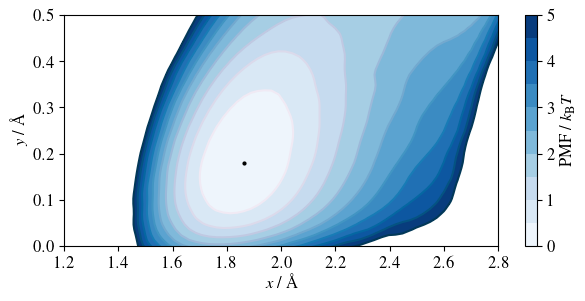

In [132]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_MB_pol_liq, Y_grid_MB_pol_liq, -np.log(Zxy_MB_pol_liq)+np.max(np.log(Zxy_MB_pol_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_MB_pol_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_MB_pol_liq[xarg][yarg], Y_grid_MB_pol_liq[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/936859727.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_scan_liq, Y_grid_scan_liq, -np.log(Zxy_scan_liq)+np.max(np.log(Zxy_scan_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


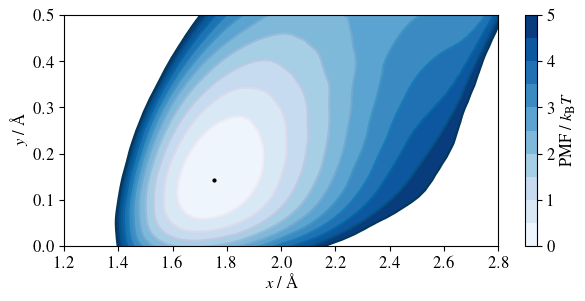

In [72]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_scan_liq, Y_grid_scan_liq, -np.log(Zxy_scan_liq)+np.max(np.log(Zxy_scan_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_scan_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_scan_liq[xarg][yarg], Y_grid_scan_liq[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/2722270770.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_scan0_liq, Y_grid_scan0_liq, -np.log(Zxy_scan0_liq)+np.max(np.log(Zxy_scan0_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


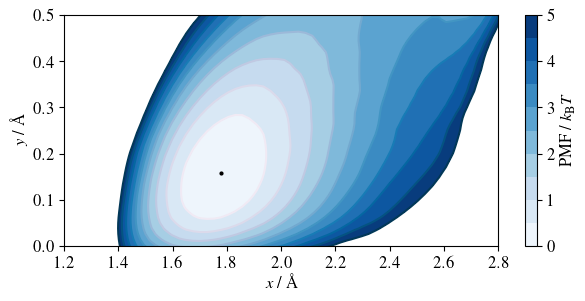

In [74]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_scan0_liq, Y_grid_scan0_liq, -np.log(Zxy_scan0_liq)+np.max(np.log(Zxy_scan0_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_scan0_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_scan0_liq[xarg][yarg], Y_grid_scan0_liq[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/470100492.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_revPBE_D3_liq, Y_grid_revPBE_D3_liq, -np.log(Zxy_revPBE_D3_liq)+np.max(np.log(Zxy_revPBE_D3_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


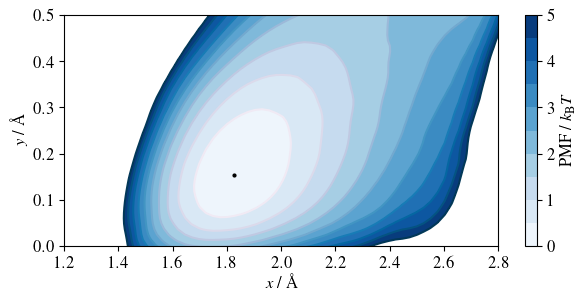

In [75]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_revPBE_D3_liq, Y_grid_revPBE_D3_liq, -np.log(Zxy_revPBE_D3_liq)+np.max(np.log(Zxy_revPBE_D3_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_revPBE_D3_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_revPBE_D3_liq[xarg][yarg], Y_grid_revPBE_D3_liq[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/2525740090.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_revPBE0_D3_liq, Y_grid_revPBE0_D3_liq, -np.log(Zxy_revPBE0_D3_liq)+np.max(np.log(Zxy_revPBE0_D3_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


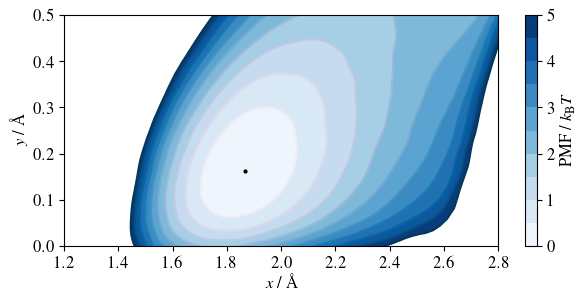

In [76]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_revPBE0_D3_liq, Y_grid_revPBE0_D3_liq, -np.log(Zxy_revPBE0_D3_liq)+np.max(np.log(Zxy_revPBE0_D3_liq[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_revPBE0_D3_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_revPBE0_D3_liq[xarg][yarg], Y_grid_revPBE0_D3_liq[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/511670454.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_MB_pol_ice, Y_grid_MB_pol_ice, -np.log(Zxy_MB_pol_ice)+np.max(np.log(Zxy_MB_pol_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


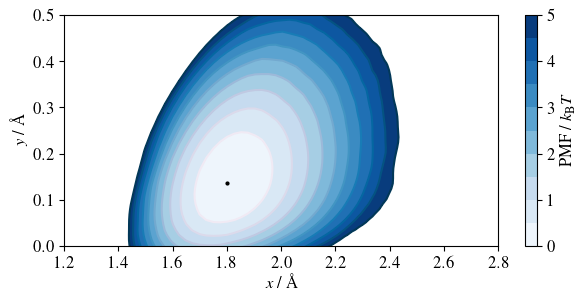

In [143]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_MB_pol_ice, Y_grid_MB_pol_ice, -np.log(Zxy_MB_pol_ice)+np.max(np.log(Zxy_MB_pol_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_MB_pol_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_MB_pol_ice[xarg][yarg], Y_grid_MB_pol_ice[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/1668596609.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_revPBE_D3_ice, Y_grid_revPBE_D3_ice, -np.log(Zxy_revPBE_D3_ice)+np.max(np.log(Zxy_revPBE_D3_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


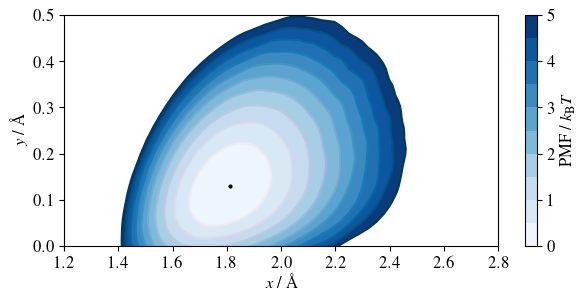

In [144]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_revPBE_D3_ice, Y_grid_revPBE_D3_ice, -np.log(Zxy_revPBE_D3_ice)+np.max(np.log(Zxy_revPBE_D3_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_revPBE_D3_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_revPBE_D3_ice[xarg][yarg], Y_grid_revPBE_D3_ice[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/3226275946.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_revPBE0_D3_ice, Y_grid_revPBE0_D3_ice, -np.log(Zxy_revPBE0_D3_ice)+np.max(np.log(Zxy_revPBE0_D3_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


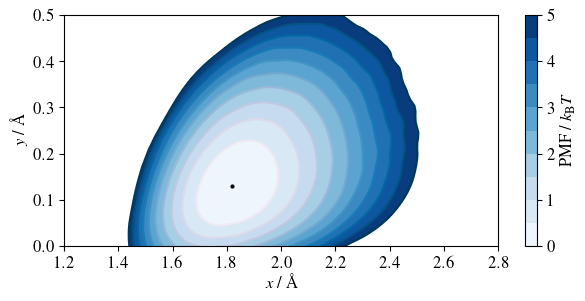

In [145]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_revPBE0_D3_ice, Y_grid_revPBE0_D3_ice, -np.log(Zxy_revPBE0_D3_ice)+np.max(np.log(Zxy_revPBE0_D3_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_revPBE0_D3_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_revPBE0_D3_ice[xarg][yarg], Y_grid_revPBE0_D3_ice[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/3095002645.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_scan_ice, Y_grid_scan_ice, -np.log(Zxy_scan_ice)+np.max(np.log(Zxy_scan_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


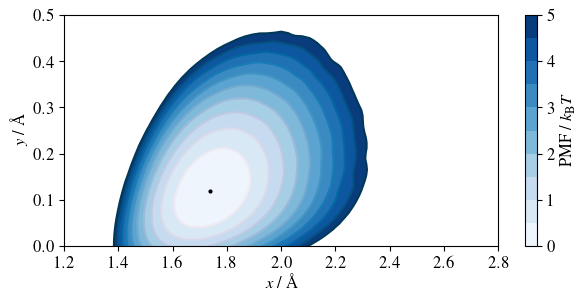

In [146]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_scan_ice, Y_grid_scan_ice, -np.log(Zxy_scan_ice)+np.max(np.log(Zxy_scan_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_scan_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_scan_ice[xarg][yarg], Y_grid_scan_ice[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

/tmp/ipykernel_11112/2340003354.py:15: RuntimeWarning: divide by zero encountered in log
  contour = plt.contourf(X_grid_scan0_ice, Y_grid_scan0_ice, -np.log(Zxy_scan0_ice)+np.max(np.log(Zxy_scan0_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)


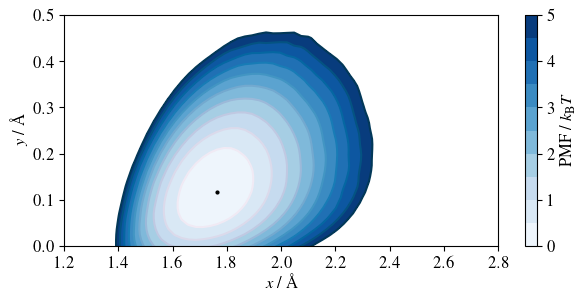

In [147]:
plt.figure(figsize=(7, 3))

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1, 0.1), fontsize=12)

plt.xlim(1.2, 2.8)
plt.ylim(0.0, 0.5)

plt.xlabel("$x$ / \AA", fontsize=12)
plt.ylabel("$y$ / \AA", fontsize=12)

vmin = 0
vmax = 5
levels = np.linspace(vmin, vmax, 11)
contour = plt.contourf(X_grid_scan0_ice, Y_grid_scan0_ice, -np.log(Zxy_scan0_ice)+np.max(np.log(Zxy_scan0_ice[:, :50])), levels=levels, cmap='Blues', vmax=vmax)
plt.contour(contour, cmap='PuBu')

max_arg = np.argmax(Zxy_scan0_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

plt.plot(X_grid_scan0_ice[xarg][yarg], Y_grid_scan0_ice[xarg][yarg], marker="o", color="black", markersize=2)
cbar = plt.colorbar(contour)

cbar.ax.tick_params(labelsize=12)  # Set the fontsize for the colorbar ticks
cbar.set_label('PMF / $k_{\mathrm{B}}T$', fontsize=12) 

In [187]:
PMF_MB_pol_liq = -np.log(Zxy_MB_pol_liq)+np.max(np.log(Zxy_MB_pol_liq[:, :50]))
max_arg = np.argmax(Zxy_MB_pol_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_MB_pol_liq[xarg][yarg+1] - X_grid_MB_pol_liq[xarg][yarg]
dy = Y_grid_MB_pol_liq[xarg+1][yarg] - Y_grid_MB_pol_liq[xarg][yarg]

f00 = PMF_MB_pol_liq[xarg][yarg]

f10 = PMF_MB_pol_liq[xarg][yarg+1]
f_10 = PMF_MB_pol_liq[xarg][yarg-1]
f01 = PMF_MB_pol_liq[xarg+1][yarg]
f0_1 = PMF_MB_pol_liq[xarg-1][yarg]

f11 = PMF_MB_pol_liq[xarg+1][yarg+1]
f_11 = PMF_MB_pol_liq[xarg+1][yarg-1]
f1_1 = PMF_MB_pol_liq[xarg-1][yarg+1]
f_1_1 = PMF_MB_pol_liq[xarg-1][yarg-1]

Hessian_MB_pol_liq_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_MB_pol_liq_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_MB_pol_liq_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/2665037088.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_MB_pol_liq = -np.log(Zxy_MB_pol_liq)+np.max(np.log(Zxy_MB_pol_liq[:, :50]))


In [188]:
PMF_MB_pol_liq[xarg][yarg]

0.0

In [200]:
PMF_MB_pol_ice = -np.log(Zxy_MB_pol_ice)+np.max(np.log(Zxy_MB_pol_ice[:, :50]))
max_arg = np.argmax(Zxy_MB_pol_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_MB_pol_ice[xarg][yarg+1] - X_grid_MB_pol_ice[xarg][yarg]
dy = Y_grid_MB_pol_ice[xarg+1][yarg] - Y_grid_MB_pol_ice[xarg][yarg]

f00 = PMF_MB_pol_ice[xarg][yarg]

f10 = PMF_MB_pol_ice[xarg][yarg+1]
f_10 = PMF_MB_pol_ice[xarg][yarg-1]
f01 = PMF_MB_pol_ice[xarg+1][yarg]
f0_1 = PMF_MB_pol_ice[xarg-1][yarg]

f11 = PMF_MB_pol_ice[xarg+1][yarg+1]
f_11 = PMF_MB_pol_ice[xarg+1][yarg-1]
f1_1 = PMF_MB_pol_ice[xarg-1][yarg+1]
f_1_1 = PMF_MB_pol_ice[xarg-1][yarg-1]

Hessian_MB_pol_ice_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_MB_pol_ice_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_MB_pol_ice_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/2480245320.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_MB_pol_ice = -np.log(Zxy_MB_pol_ice)+np.max(np.log(Zxy_MB_pol_ice[:, :50]))


In [201]:
PMF_MB_pol_ice[xarg][yarg]

0.0

In [202]:
Hessian_MB_pol_ice_xx + Hessian_MB_pol_ice_yy - (Hessian_MB_pol_liq_xx + Hessian_MB_pol_liq_yy)

89.56511106610945

In [203]:
Hessian_MB_pol_ice_xx + Hessian_MB_pol_ice_yy

199.44278995863027

In [204]:
Hessian_MB_pol_liq_xx + Hessian_MB_pol_liq_yy

109.87767889252082

In [166]:
PMF_revPBE_D3_liq = -np.log(Zxy_revPBE_D3_liq)+np.max(np.log(Zxy_revPBE_D3_liq[:, :50]))
max_arg = np.argmax(Zxy_revPBE_D3_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_revPBE_D3_liq[xarg][yarg+1] - X_grid_revPBE_D3_liq[xarg][yarg]
dy = Y_grid_revPBE_D3_liq[xarg+1][yarg] - Y_grid_revPBE_D3_liq[xarg][yarg]

f00 = PMF_revPBE_D3_liq[xarg][yarg]

f10 = PMF_revPBE_D3_liq[xarg][yarg+1]
f_10 = PMF_revPBE_D3_liq[xarg][yarg-1]
f01 = PMF_revPBE_D3_liq[xarg+1][yarg]
f0_1 = PMF_revPBE_D3_liq[xarg-1][yarg]

f11 = PMF_revPBE_D3_liq[xarg+1][yarg+1]
f_11 = PMF_revPBE_D3_liq[xarg+1][yarg-1]
f1_1 = PMF_revPBE_D3_liq[xarg-1][yarg+1]
f_1_1 = PMF_revPBE_D3_liq[xarg-1][yarg-1]

Hessian_revPBE_D3_liq_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_revPBE_D3_liq_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_revPBE_D3_liq_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/1458972582.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_revPBE_D3_liq = -np.log(Zxy_revPBE_D3_liq)+np.max(np.log(Zxy_revPBE_D3_liq[:, :50]))


In [168]:
PMF_revPBE_D3_liq[xarg][yarg]

0.0

In [169]:
PMF_revPBE_D3_ice = -np.log(Zxy_revPBE_D3_ice)+np.max(np.log(Zxy_revPBE_D3_ice[:, :50]))
max_arg = np.argmax(Zxy_revPBE_D3_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_revPBE_D3_ice[xarg][yarg+1] - X_grid_revPBE_D3_ice[xarg][yarg]
dy = Y_grid_revPBE_D3_ice[xarg+1][yarg] - Y_grid_revPBE_D3_ice[xarg][yarg]

f00 = PMF_revPBE_D3_ice[xarg][yarg]

f10 = PMF_revPBE_D3_ice[xarg][yarg+1]
f_10 = PMF_revPBE_D3_ice[xarg][yarg-1]
f01 = PMF_revPBE_D3_ice[xarg+1][yarg]
f0_1 = PMF_revPBE_D3_ice[xarg-1][yarg]

f11 = PMF_revPBE_D3_ice[xarg+1][yarg+1]
f_11 = PMF_revPBE_D3_ice[xarg+1][yarg-1]
f1_1 = PMF_revPBE_D3_ice[xarg-1][yarg+1]
f_1_1 = PMF_revPBE_D3_ice[xarg-1][yarg-1]

Hessian_revPBE_D3_ice_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_revPBE_D3_ice_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_revPBE_D3_ice_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/2295520936.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_revPBE_D3_ice = -np.log(Zxy_revPBE_D3_ice)+np.max(np.log(Zxy_revPBE_D3_ice[:, :50]))


In [170]:
PMF_revPBE_D3_ice[xarg][yarg]

0.0

In [123]:
Hessian_revPBE_D3_ice_xx + Hessian_revPBE_D3_ice_yy - (Hessian_revPBE_D3_liq_xx + Hessian_revPBE_D3_liq_yy)

13.330654788323358

In [139]:
Hessian_revPBE_D3_ice_xx + Hessian_revPBE_D3_ice_yy

164.07581738517882

In [140]:
Hessian_revPBE_D3_liq_xx + Hessian_revPBE_D3_liq_yy

150.74516259685547

In [171]:
PMF_revPBE0_D3_liq = -np.log(Zxy_revPBE0_D3_liq)+np.max(np.log(Zxy_revPBE0_D3_liq[:, :50]))
max_arg = np.argmax(Zxy_revPBE0_D3_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_revPBE0_D3_liq[xarg][yarg+1] - X_grid_revPBE0_D3_liq[xarg][yarg]
dy = Y_grid_revPBE0_D3_liq[xarg+1][yarg] - Y_grid_revPBE0_D3_liq[xarg][yarg]

f00 = PMF_revPBE0_D3_liq[xarg][yarg]

f10 = PMF_revPBE0_D3_liq[xarg][yarg+1]
f_10 = PMF_revPBE0_D3_liq[xarg][yarg-1]
f01 = PMF_revPBE0_D3_liq[xarg+1][yarg]
f0_1 = PMF_revPBE0_D3_liq[xarg-1][yarg]

f11 = PMF_revPBE0_D3_liq[xarg+1][yarg+1]
f_11 = PMF_revPBE0_D3_liq[xarg+1][yarg-1]
f1_1 = PMF_revPBE0_D3_liq[xarg-1][yarg+1]
f_1_1 = PMF_revPBE0_D3_liq[xarg-1][yarg-1]

Hessian_revPBE0_D3_liq_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_revPBE0_D3_liq_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_revPBE0_D3_liq_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/204409282.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_revPBE0_D3_liq = -np.log(Zxy_revPBE0_D3_liq)+np.max(np.log(Zxy_revPBE0_D3_liq[:, :50]))


In [172]:
PMF_revPBE0_D3_liq[xarg][yarg]

0.0

In [173]:
PMF_revPBE0_D3_ice = -np.log(Zxy_revPBE0_D3_ice)+np.max(np.log(Zxy_revPBE0_D3_ice[:, :50]))
max_arg = np.argmax(Zxy_revPBE0_D3_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_revPBE0_D3_ice[xarg][yarg+1] - X_grid_revPBE0_D3_ice[xarg][yarg]
dy = Y_grid_revPBE0_D3_ice[xarg+1][yarg] - Y_grid_revPBE0_D3_ice[xarg][yarg]

f00 = PMF_revPBE0_D3_ice[xarg][yarg]

f10 = PMF_revPBE0_D3_ice[xarg][yarg+1]
f_10 = PMF_revPBE0_D3_ice[xarg][yarg-1]
f01 = PMF_revPBE0_D3_ice[xarg+1][yarg]
f0_1 = PMF_revPBE0_D3_ice[xarg-1][yarg]

f11 = PMF_revPBE0_D3_ice[xarg+1][yarg+1]
f_11 = PMF_revPBE0_D3_ice[xarg+1][yarg-1]
f1_1 = PMF_revPBE0_D3_ice[xarg-1][yarg+1]
f_1_1 = PMF_revPBE0_D3_ice[xarg-1][yarg-1]

Hessian_revPBE0_D3_ice_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_revPBE0_D3_ice_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_revPBE0_D3_ice_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/708417859.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_revPBE0_D3_ice = -np.log(Zxy_revPBE0_D3_ice)+np.max(np.log(Zxy_revPBE0_D3_ice[:, :50]))


In [175]:
PMF_revPBE0_D3_ice[xarg][yarg]

0.0

In [176]:
Hessian_revPBE0_D3_ice_xx + Hessian_revPBE0_D3_ice_yy - (Hessian_revPBE0_D3_liq_xx + Hessian_revPBE0_D3_liq_yy)

15.627368671089783

In [177]:
Hessian_revPBE0_D3_ice_xx + Hessian_revPBE0_D3_ice_yy

139.66807999572583

In [178]:
Hessian_revPBE0_D3_liq_xx + Hessian_revPBE0_D3_liq_yy

124.04071132463605

In [180]:
PMF_scan_liq = -np.log(Zxy_scan_liq)+np.max(np.log(Zxy_scan_liq[:, :50]))
max_arg = np.argmax(Zxy_scan_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_scan_liq[xarg][yarg+1] - X_grid_scan_liq[xarg][yarg]
dy = Y_grid_scan_liq[xarg+1][yarg] - Y_grid_scan_liq[xarg][yarg]

f00 = PMF_scan_liq[xarg][yarg]

f10 = PMF_scan_liq[xarg][yarg+1]
f_10 = PMF_scan_liq[xarg][yarg-1]
f01 = PMF_scan_liq[xarg+1][yarg]
f0_1 = PMF_scan_liq[xarg-1][yarg]

f11 = PMF_scan_liq[xarg+1][yarg+1]
f_11 = PMF_scan_liq[xarg+1][yarg-1]
f1_1 = PMF_scan_liq[xarg-1][yarg+1]
f_1_1 = PMF_scan_liq[xarg-1][yarg-1]

Hessian_scan_liq_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_scan_liq_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_scan_liq_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/3090645085.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_scan_liq = -np.log(Zxy_scan_liq)+np.max(np.log(Zxy_scan_liq[:, :50]))


In [181]:
PMF_scan_liq[xarg][yarg]

0.0

In [182]:
PMF_scan_ice = -np.log(Zxy_scan_ice)+np.max(np.log(Zxy_scan_ice[:, :50]))
max_arg = np.argmax(Zxy_scan_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_scan_ice[xarg][yarg+1] - X_grid_scan_ice[xarg][yarg]
dy = Y_grid_scan_ice[xarg+1][yarg] - Y_grid_scan_ice[xarg][yarg]

f00 = PMF_scan_ice[xarg][yarg]

f10 = PMF_scan_ice[xarg][yarg+1]
f_10 = PMF_scan_ice[xarg][yarg-1]
f01 = PMF_scan_ice[xarg+1][yarg]
f0_1 = PMF_scan_ice[xarg-1][yarg]

f11 = PMF_scan_ice[xarg+1][yarg+1]
f_11 = PMF_scan_ice[xarg+1][yarg-1]
f1_1 = PMF_scan_ice[xarg-1][yarg+1]
f_1_1 = PMF_scan_ice[xarg-1][yarg-1]

Hessian_scan_ice_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_scan_ice_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_scan_ice_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/3403603368.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_scan_ice = -np.log(Zxy_scan_ice)+np.max(np.log(Zxy_scan_ice[:, :50]))


In [183]:
PMF_scan_ice[xarg][yarg]

0.0

In [184]:
Hessian_scan_ice_xx + Hessian_scan_ice_yy - (Hessian_scan_liq_xx + Hessian_scan_liq_yy)

69.97251005091613

In [185]:
Hessian_scan_ice_xx + Hessian_scan_ice_yy

240.0265382227417

In [186]:
Hessian_scan_liq_xx + Hessian_scan_liq_yy

170.05402817182556

In [195]:
PMF_scan0_liq = -np.log(Zxy_scan0_liq)+np.max(np.log(Zxy_scan0_liq[:, :50]))
max_arg = np.argmax(Zxy_scan0_liq[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_scan0_liq[xarg][yarg+1] - X_grid_scan0_liq[xarg][yarg]
dy = Y_grid_scan0_liq[xarg+1][yarg] - Y_grid_scan0_liq[xarg][yarg]

f00 = PMF_scan0_liq[xarg][yarg]

f10 = PMF_scan0_liq[xarg][yarg+1]
f_10 = PMF_scan0_liq[xarg][yarg-1]
f01 = PMF_scan0_liq[xarg+1][yarg]
f0_1 = PMF_scan0_liq[xarg-1][yarg]

f11 = PMF_scan0_liq[xarg+1][yarg+1]
f_11 = PMF_scan0_liq[xarg+1][yarg-1]
f1_1 = PMF_scan0_liq[xarg-1][yarg+1]
f_1_1 = PMF_scan0_liq[xarg-1][yarg-1]

Hessian_scan0_liq_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_scan0_liq_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_scan0_liq_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/807229995.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_scan0_liq = -np.log(Zxy_scan0_liq)+np.max(np.log(Zxy_scan0_liq[:, :50]))


In [196]:
PMF_scan0_liq[xarg][yarg]

0.0

In [198]:
PMF_scan0_ice = -np.log(Zxy_scan0_ice)+np.max(np.log(Zxy_scan0_ice[:, :50]))
max_arg = np.argmax(Zxy_scan0_ice[:, :50])
xarg = max_arg // 50
yarg = max_arg - 50 * xarg

dx = X_grid_scan0_ice[xarg][yarg+1] - X_grid_scan0_ice[xarg][yarg]
dy = Y_grid_scan0_ice[xarg+1][yarg] - Y_grid_scan0_ice[xarg][yarg]

f00 = PMF_scan0_ice[xarg][yarg]

f10 = PMF_scan0_ice[xarg][yarg+1]
f_10 = PMF_scan0_ice[xarg][yarg-1]
f01 = PMF_scan0_ice[xarg+1][yarg]
f0_1 = PMF_scan0_ice[xarg-1][yarg]

f11 = PMF_scan0_ice[xarg+1][yarg+1]
f_11 = PMF_scan0_ice[xarg+1][yarg-1]
f1_1 = PMF_scan0_ice[xarg-1][yarg+1]
f_1_1 = PMF_scan0_ice[xarg-1][yarg-1]

Hessian_scan0_ice_xx = (f10 + f_10 - 2 * f00) / dx**2
Hessian_scan0_ice_yy = (f01 + f0_1 - 2 * f00) / dy**2
Hessian_scan0_ice_xy = (f11 + f_1_1 - f1_1 - f_11) / (4 * dx * dy)

/tmp/ipykernel_11112/2275322909.py:1: RuntimeWarning: divide by zero encountered in log
  PMF_scan0_ice = -np.log(Zxy_scan0_ice)+np.max(np.log(Zxy_scan0_ice[:, :50]))


In [199]:
PMF_scan0_ice[xarg][yarg]

0.0

In [126]:
Hessian_scan0_ice_xx + Hessian_scan0_ice_yy - (Hessian_scan0_liq_xx + Hessian_scan0_liq_yy)

67.06861522826028

In [135]:
Hessian_scan0_ice_xx + Hessian_scan0_ice_yy

221.86187465200942

In [136]:
Hessian_scan0_liq_xx + Hessian_scan0_liq_yy

154.79325942374913